# **Procesamiento de Lenguaje Natural**

## Maestría en Inteligencia Artificial Aplicada
#### Tecnológico de Monterrey
#### Prof Luis Eduardo Falcón Morales

### **Adtividad en Equipos Semanas  RAG CHATBOT


Construct a QA Bot that Leverages LangChain and LLMs to Answer Questions from Loaded Documents
Estimated time needed: 60 minutes

In this project, you will construct a question-answering (QA) bot. This bot will leverage LangChain and a large language model (LLM) to answer questions based on content from loaded PDF documents. To build a fully functional QA system, you'll combine various components, including document loaders, text splitters, embedding models, vector databases, retrievers, and Gradio as the front-end interface.

Imagine you're tasked with creating an intelligent assistant that can quickly and accurately respond to queries based on a company's extensive library of PDF documents. This could be anything from legal documents to technical manuals. Manually searching through these documents would be time-consuming and inefficient.

* **Nombres y matrículas:**

  *   Jose Angel Barajas A01797221
  *   Elemento de lista
  *   Elemento de lista

* **Número de Equipo:**


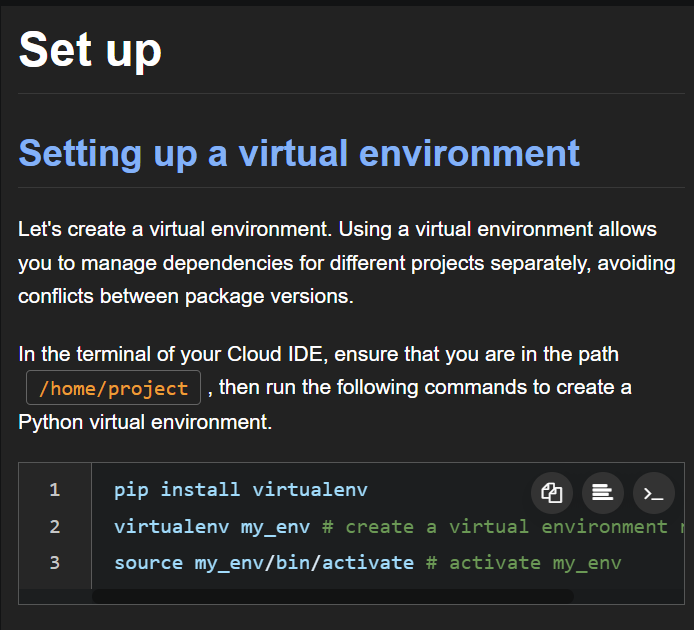

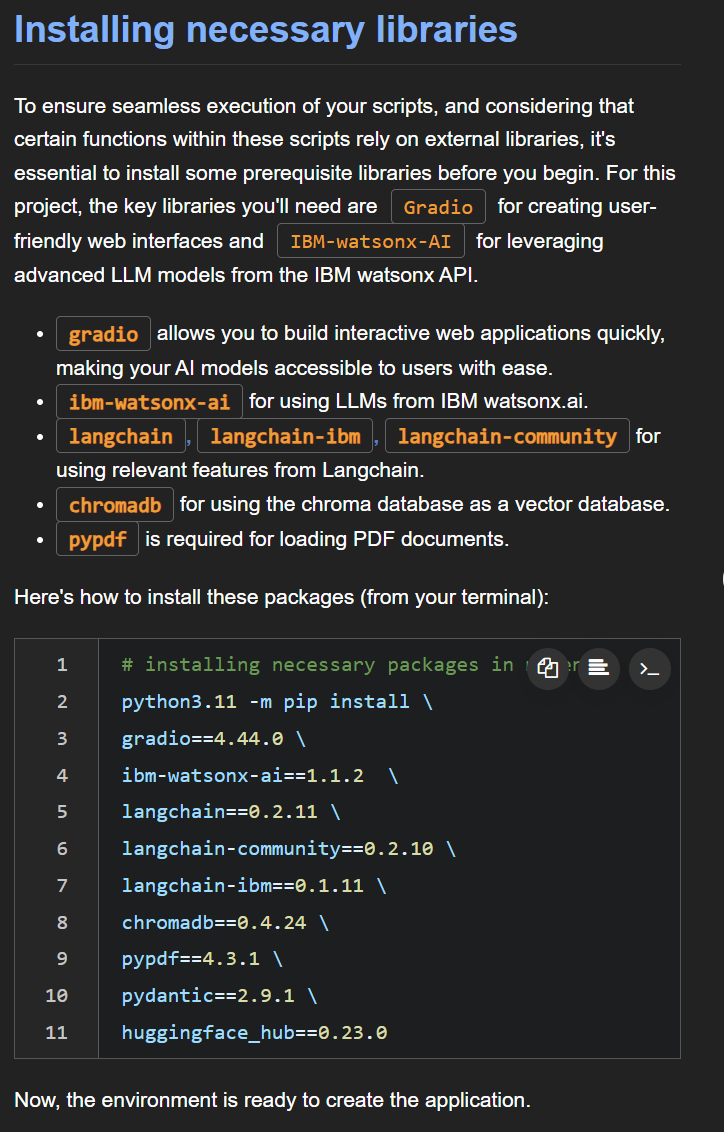

🧩 Step 1 – Install the required packages

In your VS Code notebook, create a first cell and run:

In [2]:
!pip install langchain
!pip install langchain-classic 
!pip install langchain-community
!pip install langchain-openai
!pip install langchain-huggingface
!pip install chromadb
!pip install pypdf
!pip install sentence-transformers
!pip install gradio
!pip install openai

⚙️ Step 2 – Imports + connect to Llama in LM Studio

In [3]:
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import Chroma
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_classic.chains import RetrievalQA
from langchain_openai import ChatOpenAI

import gradio as gr
import os

os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"
os.environ["HF_HUB_OFFLINE"] = "1"

C:\Users\baraj\AppData\Local\Temp\ipykernel_80620\1976649715.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader


Step 3 Configure LLM Pointing to LM Studio 

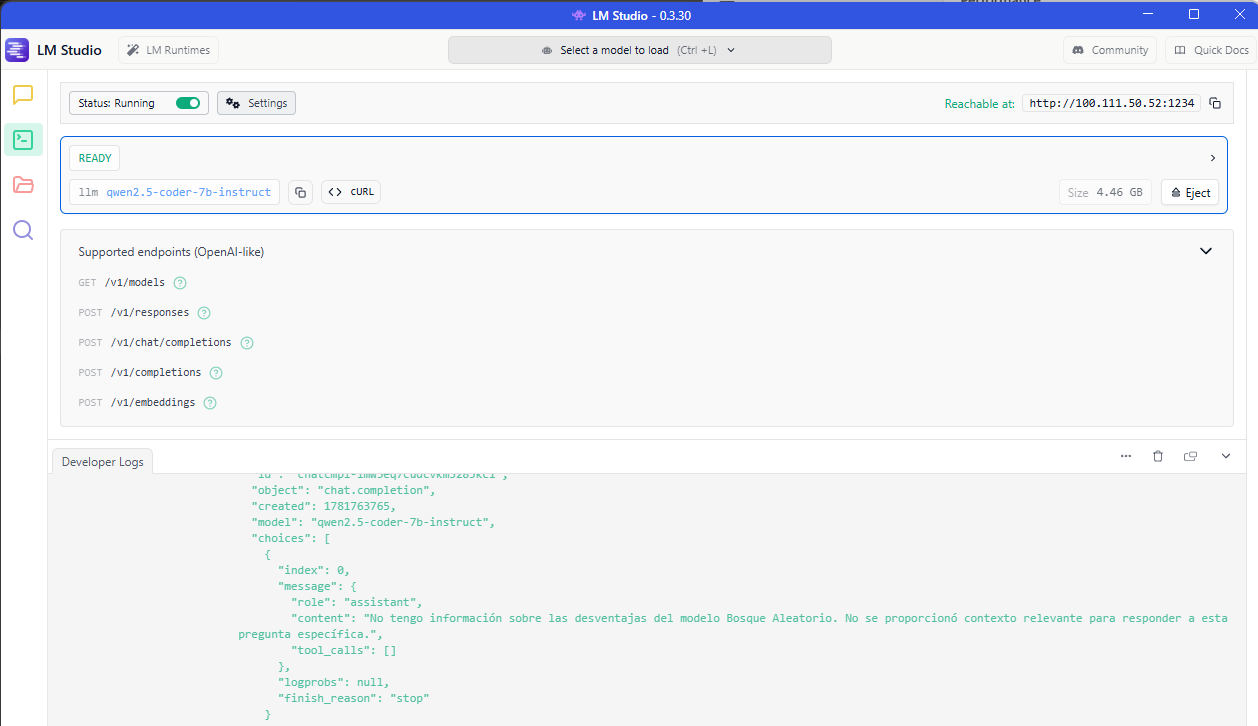

Step 3.1 - Establecer comunicacion con LM Studio

In [4]:
# LLM config for LM Studio
LMSTUDIO_BASE_URL = "http://100.111.50.52:1234/v1"   # note the /v1
LMSTUDIO_MODEL    = "qwen2.5-coder-7b-instruct"    # from LM Studio "API identifier"

from langchain_openai import ChatOpenAI

def get_llm():
    llm = ChatOpenAI(
        base_url=LMSTUDIO_BASE_URL,
        api_key="not-needed",     # LM Studio doesn't check this, but parameter is required
        model=LMSTUDIO_MODEL,
        temperature=0.5,
        max_tokens=1024,
    )
    return llm


Step 3.2 - Hacer prueba de comunicacion con LM STudio

In [5]:
##Test
llm = get_llm()
resp = llm.invoke("Dame una respuesta corta en español diciendo que la conexión con LM Studio funciona.")
print(resp.content)

La conexión con LM Studio funciona correctamente.


Step 4 - Document loader

In [6]:
# %%
def document_loader(file_path: str):
    loader = PyPDFLoader(file_path)
    docs = loader.load()
    return docs

Step 5 - Text splitter

In [7]:
# %%
def text_splitter(docs):
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=1000,
        chunk_overlap=150,
        length_function=len,
    )
    chunks = splitter.split_documents(docs)
    return chunks

Step 6 - Embeddings + VectorDB
We’ll use a local Sentence Transformer for embeddings (no cloud):

In [8]:
# %%
def embedding_model():
    return HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")

def vector_database(chunks):
    embed = embedding_model()
    vectordb = Chroma.from_documents(documents=chunks, embedding=embed)
    return vectordb

Step 7 – Retriever + QA chain

In [9]:
# %%
def build_retriever(file_paths):
    all_docs = []
    for fp in file_paths:
        docs = document_loader(fp)
        all_docs.extend(docs)
    chunks = text_splitter(all_docs)
    vectordb = vector_database(chunks)
    return vectordb.as_retriever()

def answer_question(file_paths, question):
    llm = get_llm()
    retriever = build_retriever(file_paths)

    qa_chain = RetrievalQA.from_chain_type(
        llm=llm,
        chain_type="stuff",
        retriever=retriever,
        return_source_documents=True
    )

    result = qa_chain.invoke({"query": question})
    return result["result"]

Step 8 – Gradio interface with PDF upload

In [10]:
# %%
def gradio_rag_interface(file, query):
    if file is None or query.strip() == "":
        return "Please upload a PDF and enter a question."
    # file_count="multiple" always gives a list; normalize to list just in case
    file_paths = file if isinstance(file, list) else [file]
    return answer_question(file_paths, query)

rag_app = gr.Interface(
    fn=gradio_rag_interface,
    inputs=[
        gr.File(
            label="Upload PDF File(s)",
            file_count="multiple",
            file_types=[".pdf"],
            type="filepath"
        ),
        gr.Textbox(
            label="Your Question",
            lines=5,
            placeholder="Ask something about the PDF..."
        )
    ],
    outputs=gr.Textbox(label="Answer", lines=10),
    title="Local Llama RAG PDF QA Bot",
    description="Upload a PDF and ask questions. Answers are generated by a local Llama model via LM Studio."
)

rag_app.launch(server_name="127.0.0.1", server_port=7861)

* Running on local URL:  http://127.0.0.1:7861
* To create a public link, set `share=True` in `launch()`.


d:\ML\Projects\Project_6_TC55043.10_NLP\TC55043.10_NLP\venv\lib\site-packages\gradio\routes.py:1379: StarletteDeprecationWarning: 'HTTP_422_UNPROCESSABLE_ENTITY' is deprecated. Use 'HTTP_422_UNPROCESSABLE_CONTENT' instead.
  return await queue_join_helper(body, request, username)


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

d:\ML\Projects\Project_6_TC55043.10_NLP\TC55043.10_NLP\venv\lib\site-packages\gradio\routes.py:1379: StarletteDeprecationWarning: 'HTTP_422_UNPROCESSABLE_ENTITY' is deprecated. Use 'HTTP_422_UNPROCESSABLE_CONTENT' instead.
  return await queue_join_helper(body, request, username)


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

d:\ML\Projects\Project_6_TC55043.10_NLP\TC55043.10_NLP\venv\lib\site-packages\gradio\routes.py:1379: StarletteDeprecationWarning: 'HTTP_422_UNPROCESSABLE_ENTITY' is deprecated. Use 'HTTP_422_UNPROCESSABLE_CONTENT' instead.
  return await queue_join_helper(body, request, username)
'[WinError 10054] An existing connection was forcibly closed by the remote host' thrown while requesting HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/adapter_config.json
Retrying in 1s [Retry 1/5].
Traceback (most recent call last):
  File "d:\ML\Projects\Project_6_TC55043.10_NLP\TC55043.10_NLP\venv\lib\site-packages\gradio\queueing.py", line 867, in process_events
    response = await route_utils.call_process_api(
  File "d:\ML\Projects\Project_6_TC55043.10_NLP\TC55043.10_NLP\venv\lib\site-packages\gradio\route_utils.py", line 386, in call_process_api
    output = await app.get_blocks().process_api(
  File "d:\ML\Projects\Project_6_TC55043.10_NLP\TC55043.10_NLP\venv\lib\site

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

d:\ML\Projects\Project_6_TC55043.10_NLP\TC55043.10_NLP\venv\lib\site-packages\gradio\routes.py:1379: StarletteDeprecationWarning: 'HTTP_422_UNPROCESSABLE_ENTITY' is deprecated. Use 'HTTP_422_UNPROCESSABLE_CONTENT' instead.
  return await queue_join_helper(body, request, username)


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

1000--- THIS IS JUST TO STOP THE SERVER AND RELEASE THE PORT

In [55]:
gr.close_all()
rag_app.close()

Closing server running on port: 7861


## Preguntas 

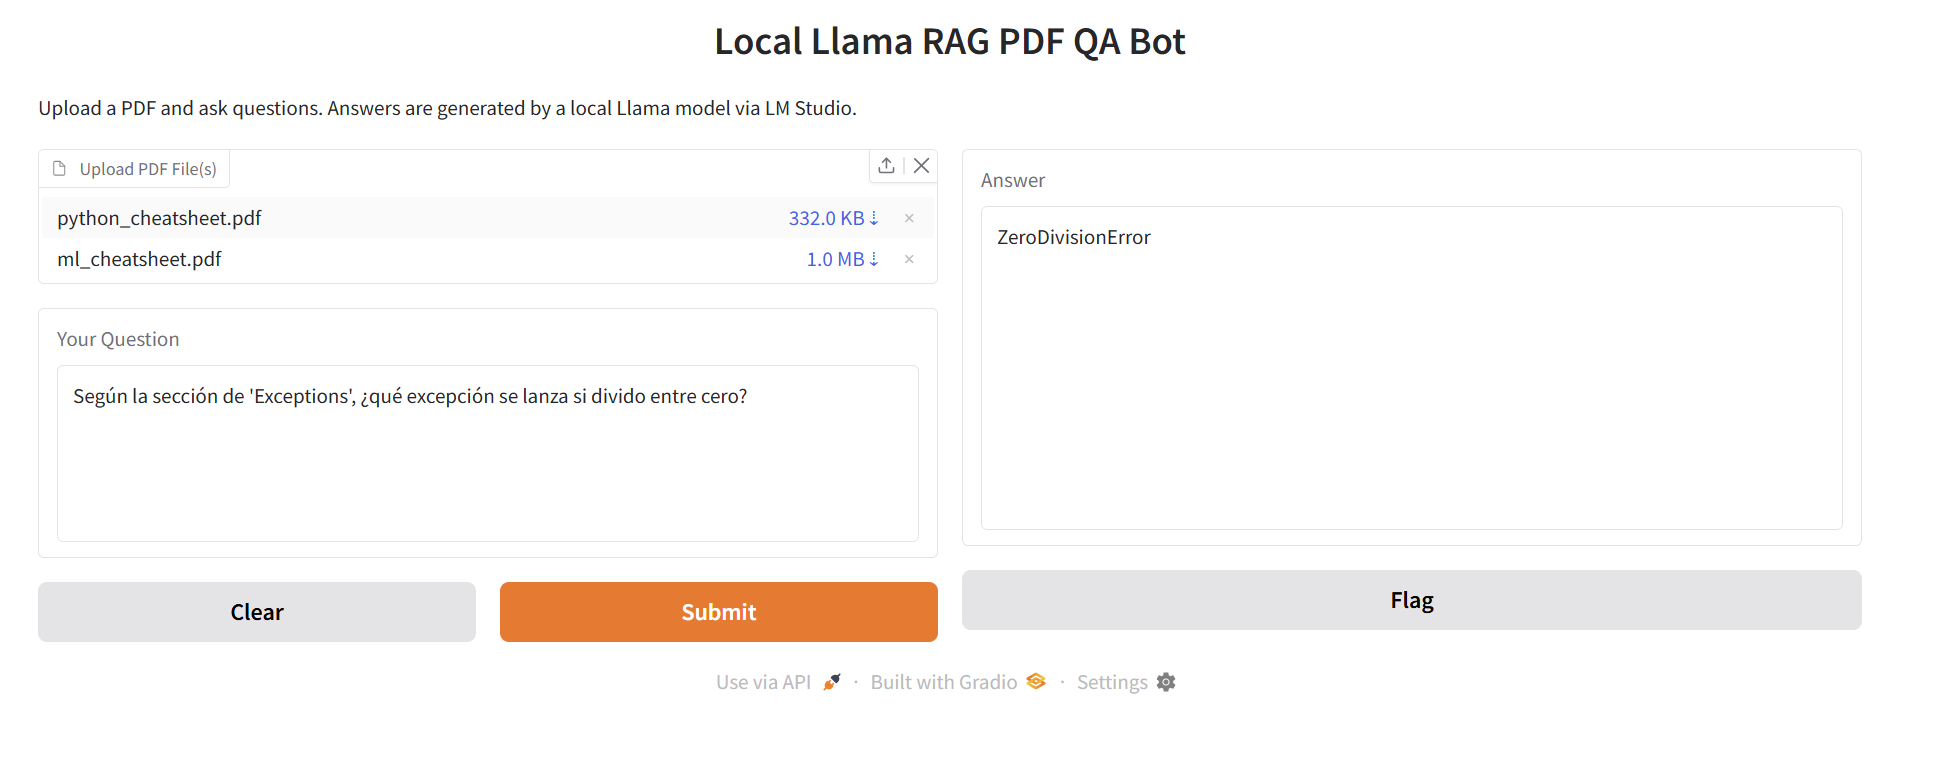

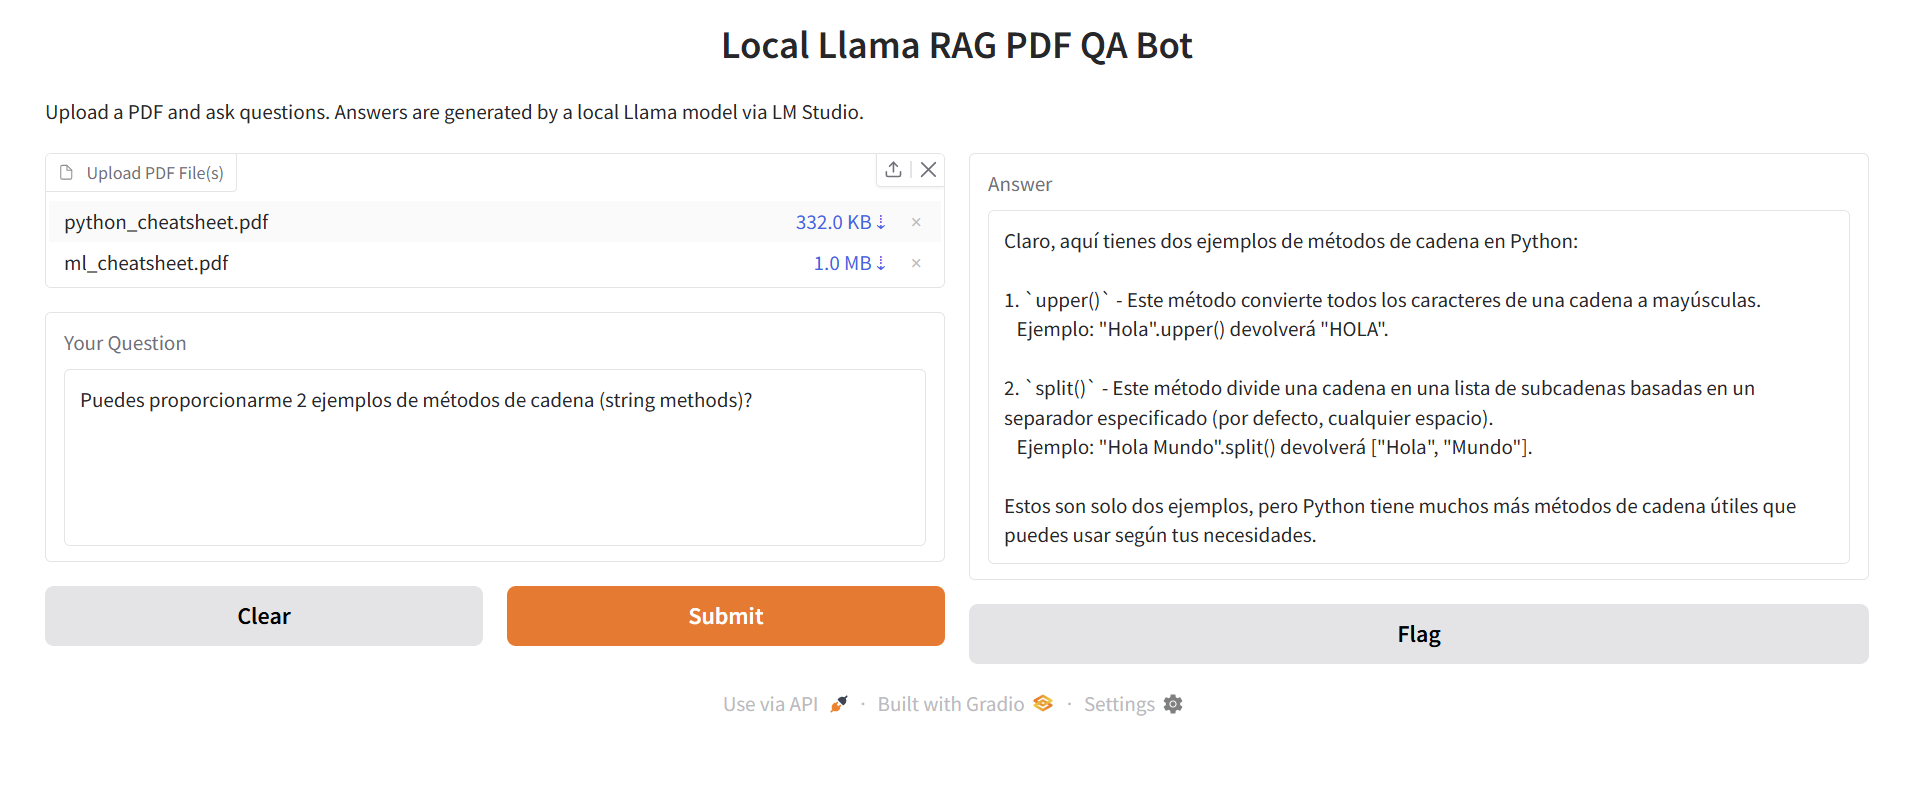

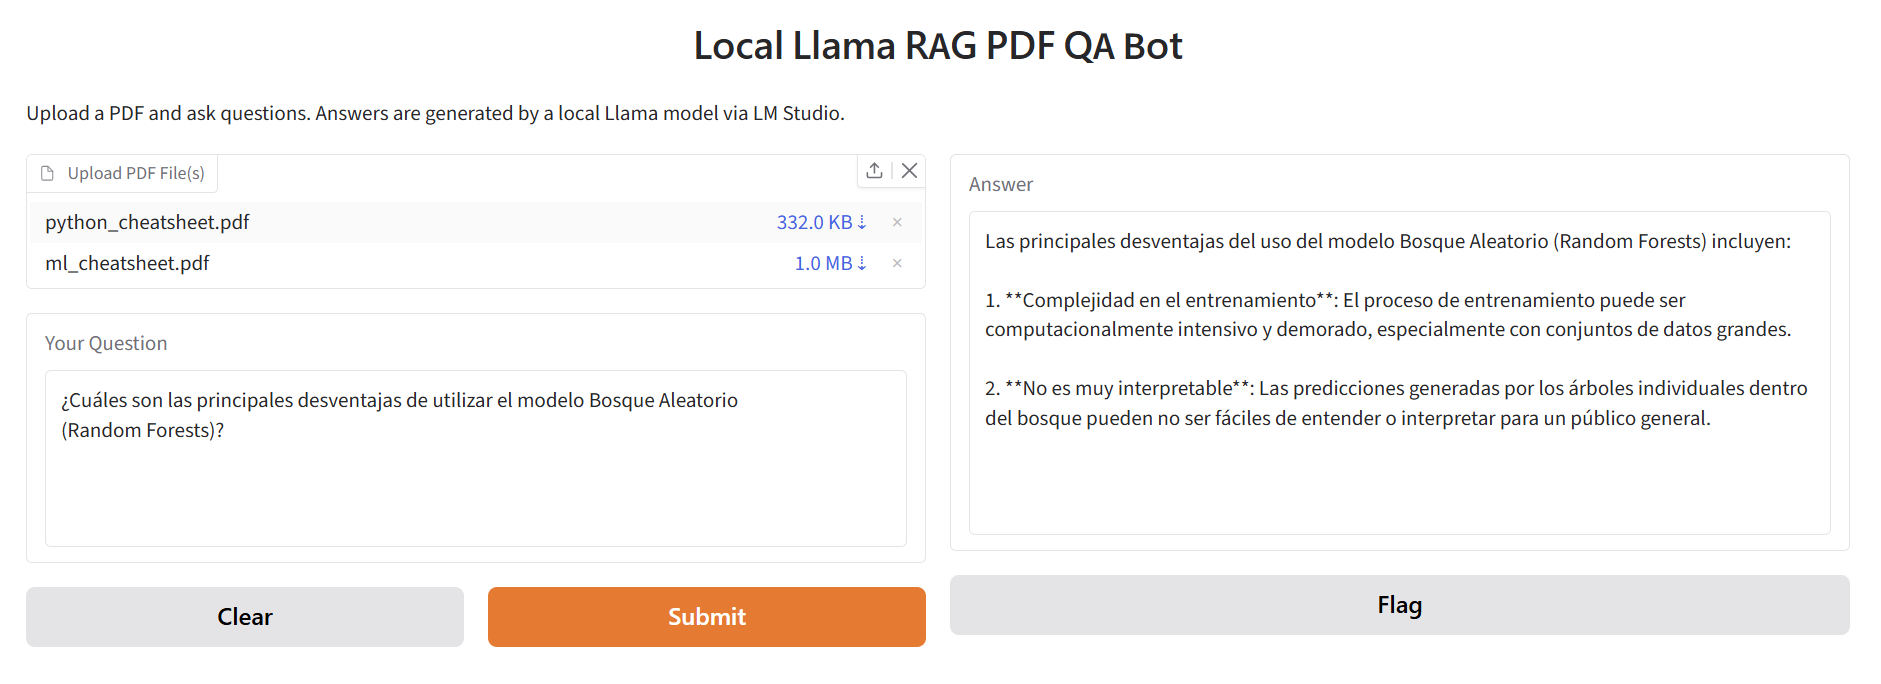

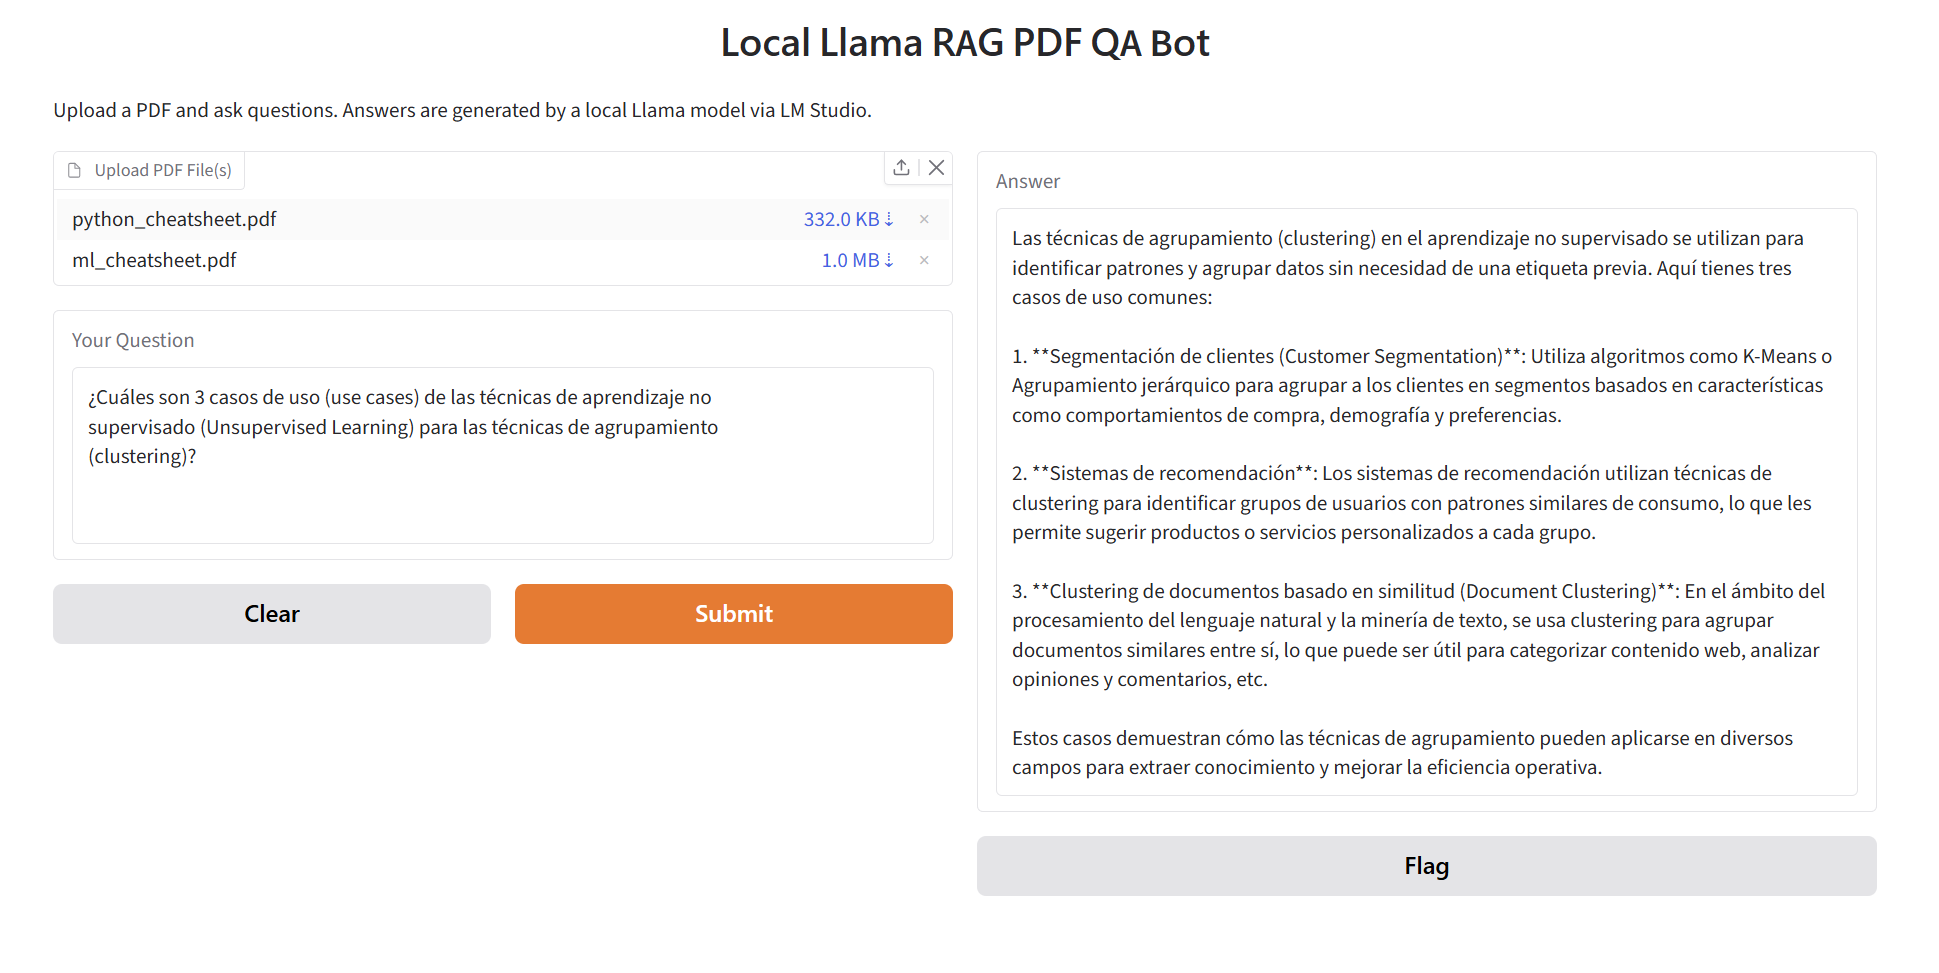

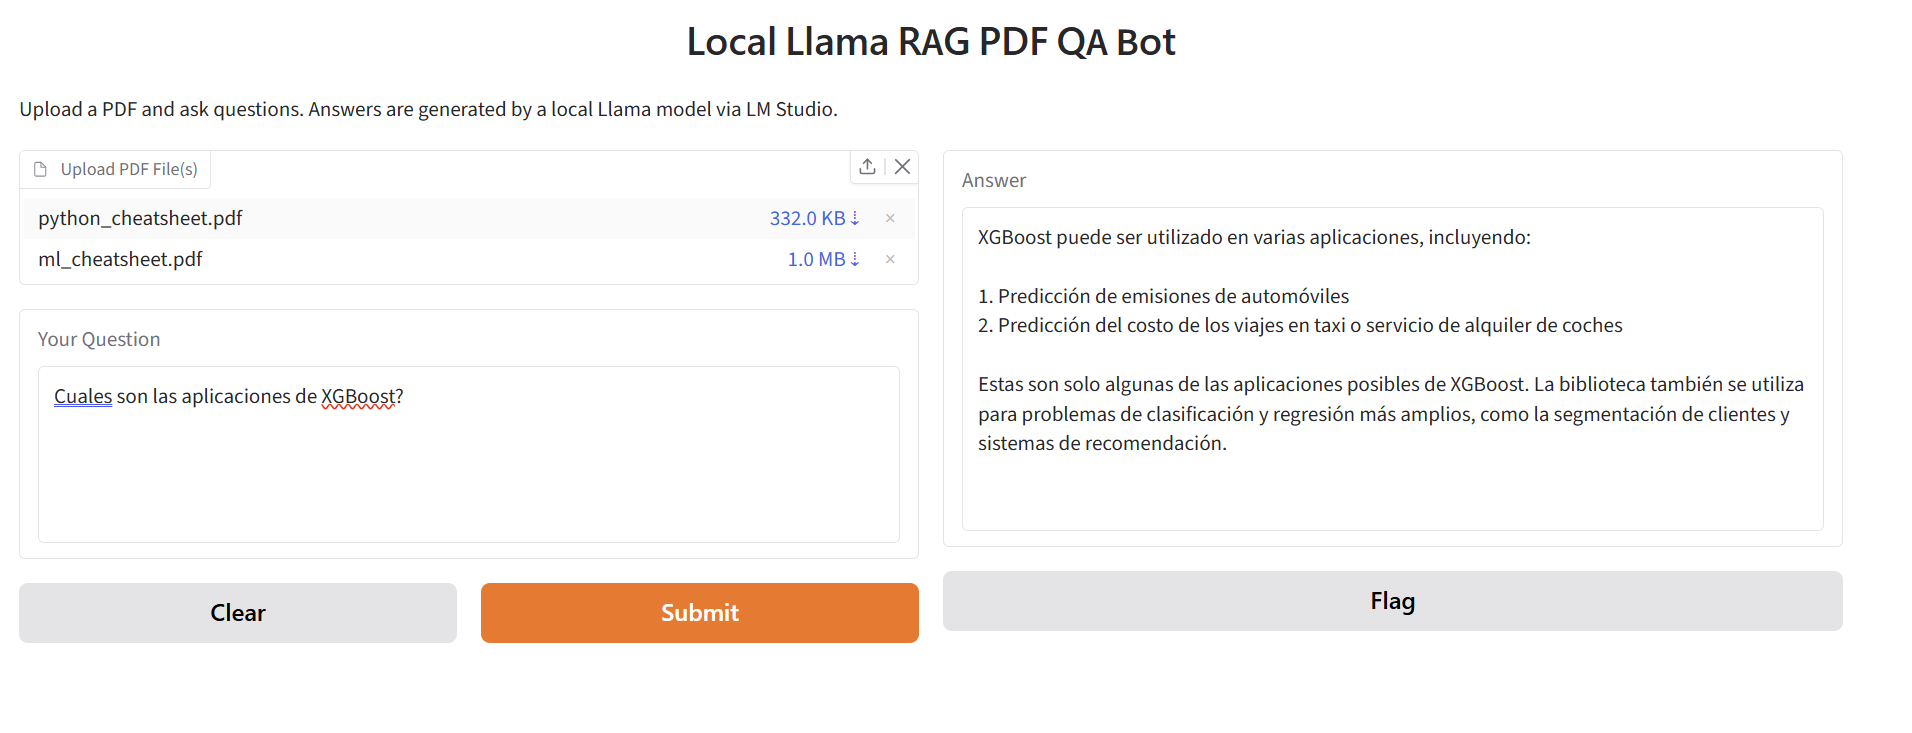

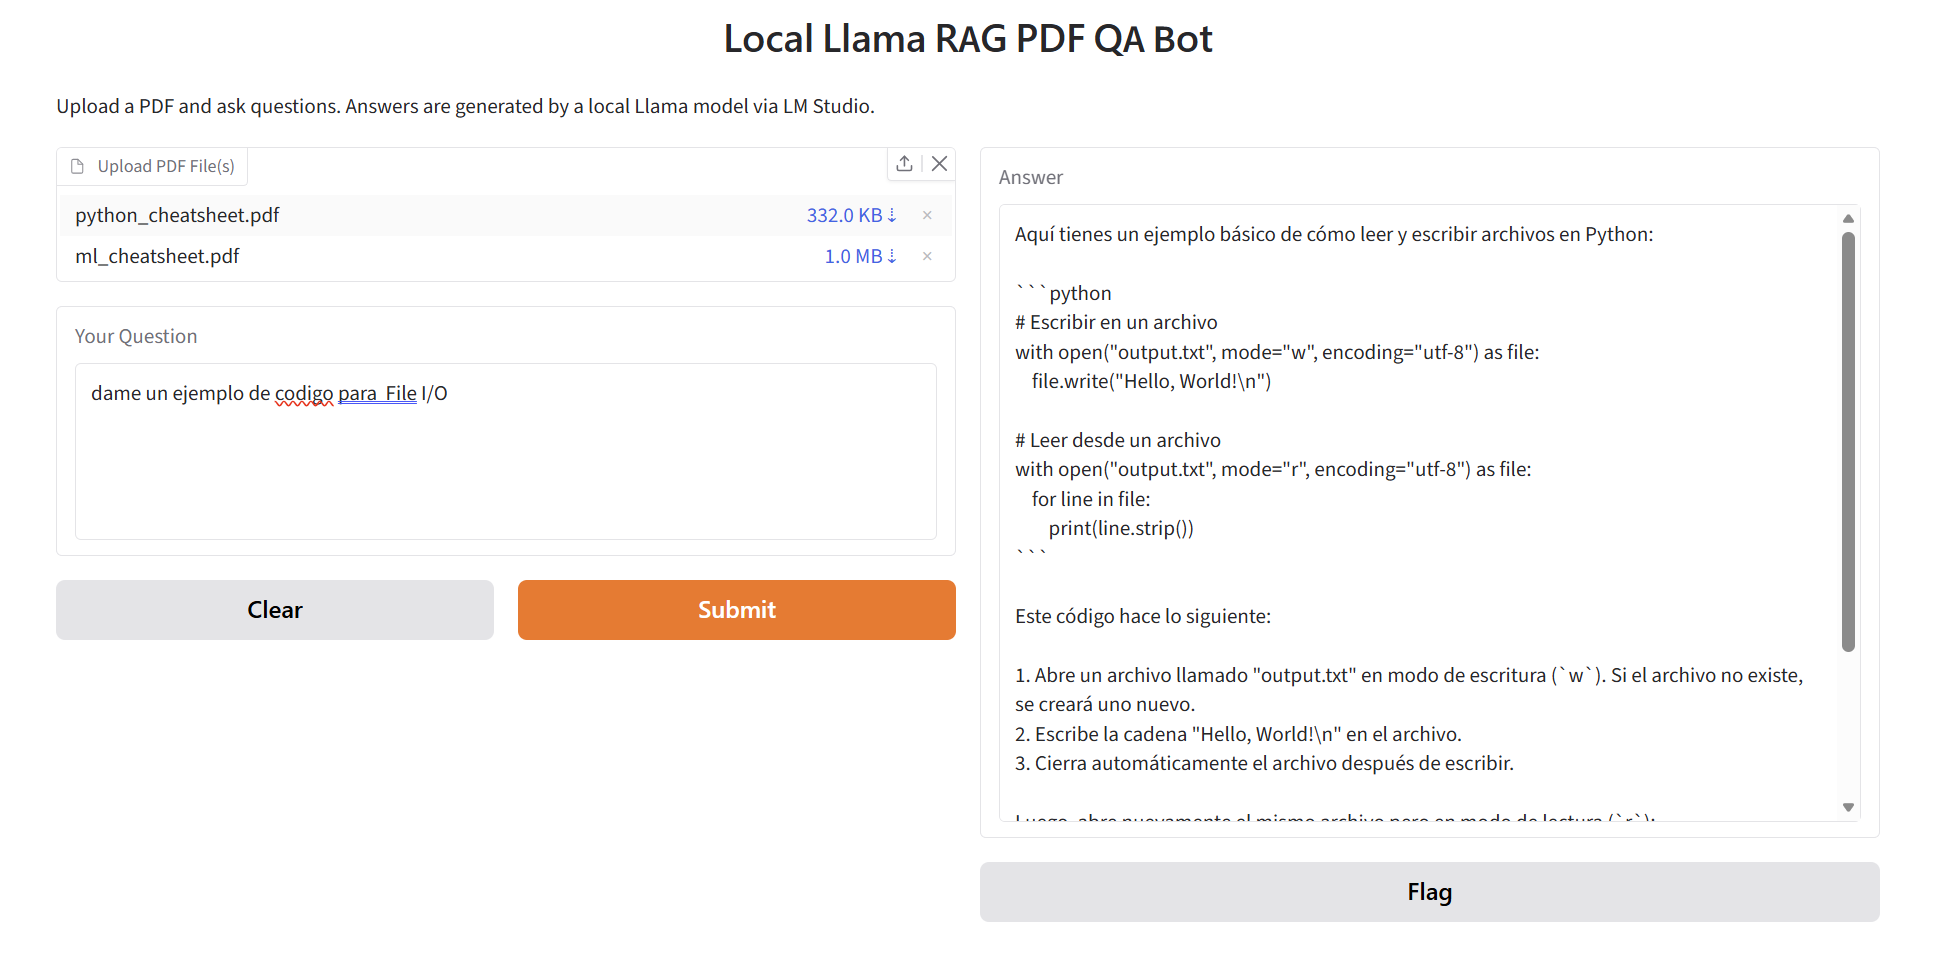